# RQ1 — Data Quality Characteristics (Q9–Q16)


### imports

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
from statsmodels.stats.multitest import multipletests

sys.path.insert(0, str(Path.cwd()))
import utils as U

U.setup_matplotlib()
TABLES = U.DATA_PROC / "tables"
TABLES.mkdir(exist_ok=True)

df = U.load_anonymized()
imp_long = pd.read_csv(U.DATA_PROC / "likert_importance.csv")
pri_long = pd.read_csv(U.DATA_PROC / "likert_priority.csv")
skills_long = pd.read_csv(U.DATA_PROC / "skills.csv")
words_long = pd.read_csv(U.DATA_PROC / "words.csv")
print(f"N={len(df)}, importance={len(imp_long)}, priority={len(pri_long)}, tokens Q9={len(words_long)}")


N=56, importance=728, priority=728, tokens Q9=279


In [ ]:
_CANDIDATE_COLS = ["canonical", "word", "palavra", "term", "token", "label"]
_WORD_COL = next((c for c in _CANDIDATE_COLS if c in words_long.columns), None)

if _WORD_COL is None:
    raise ValueError(
        f"Nenhuma coluna de palavras encontrada em words_long. "
        f"Colunas disponíveis: {list(words_long.columns)}"
    )

WORD_PT_TO_KEY: dict[str, str] = {
    "consistência":         "consistency",
    "consistencia":         "consistency",
    "completude":           "completeness",
    "confiabilidade":       "reliability",
    "precisão":             "precision",
    "precisao":             "precision",
    "balanceamento":        "balance",
    "quantidade":           "quantity",
    "atualização":          "currentness",
    "atualizacao":          "currentness",
    "outliers":             "outliers",
    "integração":           "integration",
    "integracao":           "integration",
    "normalização":         "normalization",
    "normalizacao":         "normalization",
    "relevância":           "relevance",
    "relevancia":           "relevance",
    "acurácia":             "accuracy",
    "acuracia":             "accuracy",
    "distribuição":         "distribution",
    "distribuicao":         "distribution",
    "acessibilidade":       "accessibility",
    "qualidade":            "quality",
    "qualidade de dados":   "data quality",
    "confiança":            "reliability",
    "confianca":            "reliability",
    "validade":             "validity",
    "validação":            "validation",
    "validacao":            "validation",
    "integridade":          "integrity",
    "rastreabilidade":      "traceability",
    "disponibilidade":      "availability",
    "segurança":            "security",
    "seguranca":            "security",
    "privacidade":          "privacy",
    "conformidade":         "compliance",
    "processamento":        "processing",
    "pipeline":             "pipeline",
    "estrutura":            "structure",
    "volume":               "volume",
    "frescor":              "freshness",
    "atualidade":           "currentness",
    "ruído":                "noise",
    "ruido":                "noise",
    "análise":              "analysis",
    "analise":              "analysis",
    "representatividade":   "representativeness",
    "proveniência":         "provenance",
    "proveniencia":         "provenance",
    "origem":               "provenance",
    "clareza":              "clarity",
    "compreensibilidade":   "understandability",
    "eficiência":           "efficiency",
    "eficiencia":           "efficiency",
    "duplicatas":           "duplicates",
    "metadados":            "metadata",
    "documentação":         "documentation",
    "documentacao":         "documentation",
    "governança":           "governance",
    "governanca":           "governance",
    "monitoramento":        "monitoring",
    "auditoria":            "audit",
    "credibilidade":        "credibility",
    "recuperabilidade":     "recoverability",
    "sigilo":               "confidentiality",
    "confidencialidade":    "confidentiality",
    "criptografia":         "cryptography",
    "anonimização":         "anonymization",
    "anonimizacao":         "anonymization",
    "consentimento":        "consent",
    "controle":             "control",
    "controle de acesso":   "access control",
    "pessoas":              "people",
    "lgpd":                 "lgpd",
    "proteção":             "protection",
    "protecao":             "protection",
    "padronização":         "standardization",
    "padronizacao":         "standardization",
    "transformação":        "transformation",
    "transformacao":        "transformation",
    "esquema":              "schema",
    "valores ausentes":     "missing values",
    "dados faltantes":      "missing values",
    "nulos":                "null values",
    "valores nulos":        "null values",
    "observabilidade":      "observability",
    "limpeza":              "cleaning"
}

EXTRA_DISPLAY: dict[str, str] = {
    "balance":              "Balance",
    "quantity":             "Quantity",
    "outliers":             "Outliers",
    "integration":          "Integration",
    "normalization":        "Normalization",
    "relevance":            "Relevance",
    "accuracy":             "Accuracy",
    "distribution":         "Distribution",
    "quality":              "Quality",
    "data quality":         "Data Quality",
    "validity":             "Validity",
    "validation":           "Validation",
    "integrity":            "Integrity",
    "security":             "Security",
    "privacy":              "Privacy",
    "processing":           "Processing",
    "pipeline":             "Pipeline",
    "structure":            "Structure",
    "volume":               "Volume",
    "freshness":            "Freshness",
    "noise":                "Noise",
    "analysis":             "Analysis",
    "representativeness":   "Representativeness",
    "provenance":           "Provenance",
    "clarity":              "Clarity",
    "duplicates":           "Duplicates",
    "metadata":             "Metadata",
    "documentation":        "Documentation",
    "governance":           "Governance",
    "monitoring":           "Monitoring",
    "audit":                "Audit",
    "cryptography":         "Cryptography",
    "anonymization":        "Anonymization",
    "consent":              "Consent",
    "control":              "Control",
    "access control":       "Access Control",
    "people":               "People",
    "lgpd":                 "LGPD",
    "confidentiality":      "Confidentiality",
    "protection":           "Protection",
    "standardization":      "Standardization",
    "transformation":       "Transformation",
    "schema":               "Schema",
    "missing values":       "Missing Values",
    "null values":          "Null Values",
    "observability":        "Observability",
}

# U.CHARACTERISTICS_EN tem prioridade (13 características oficiais do paper)
ALL_DISPLAY: dict[str, str] = {**EXTRA_DISPLAY, **U.CHARACTERISTICS_EN}


def normalize_to_en(word: str) -> str:
    """PT word → chave EN curta → label de display oficial."""
    if not isinstance(word, str):
        return word
    w = word.strip().lower()
    key = WORD_PT_TO_KEY.get(w, w)
    return ALL_DISPLAY.get(key, key.capitalize())


# Valores inválidos a descartar (células vazias, traços, placeholders)
_INVALID_VALUES = {"", "-", "--", "n/a", "na", "none", "null", "nan"}


def is_valid_word(word) -> bool:
    """Retorna False para NaN, None, strings vazias ou placeholders."""
    if not isinstance(word, str):
        return False
    return word.strip().lower() not in _INVALID_VALUES


TOP_N = 5

words_long_en = words_long.copy()
words_long_en = words_long_en[words_long_en[_WORD_COL].apply(is_valid_word)].copy()

words_long_en[_WORD_COL] = words_long_en[_WORD_COL].apply(normalize_to_en)

by_pos_full = (
    words_long_en
    .groupby([_WORD_COL, "position"])
    .size()
    .unstack(fill_value=0)
)

positions = [1, 2, 3, 4, 5]
top_words_per_pos = {}
for pos in positions:
    if pos in by_pos_full.columns:
        top_words_per_pos[pos] = by_pos_full[pos].nlargest(TOP_N)

all_top_words = sorted(set(
    w for words in top_words_per_pos.values() for w in words.index
))

cmap = plt.cm.get_cmap('tab20', len(all_top_words))
word_colors = {w: cmap(i) for i, w in enumerate(all_top_words)}

C:\Users\kevin\AppData\Local\Temp\ipykernel_21528\4245327393.py:200: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', len(all_top_words))


WindowsPath('C:/dev/qualidade-de-dados-em-sistemas-aprendizado-de-maquina/figures/../figures/q9_top_words_by_position.pdf.pdf')

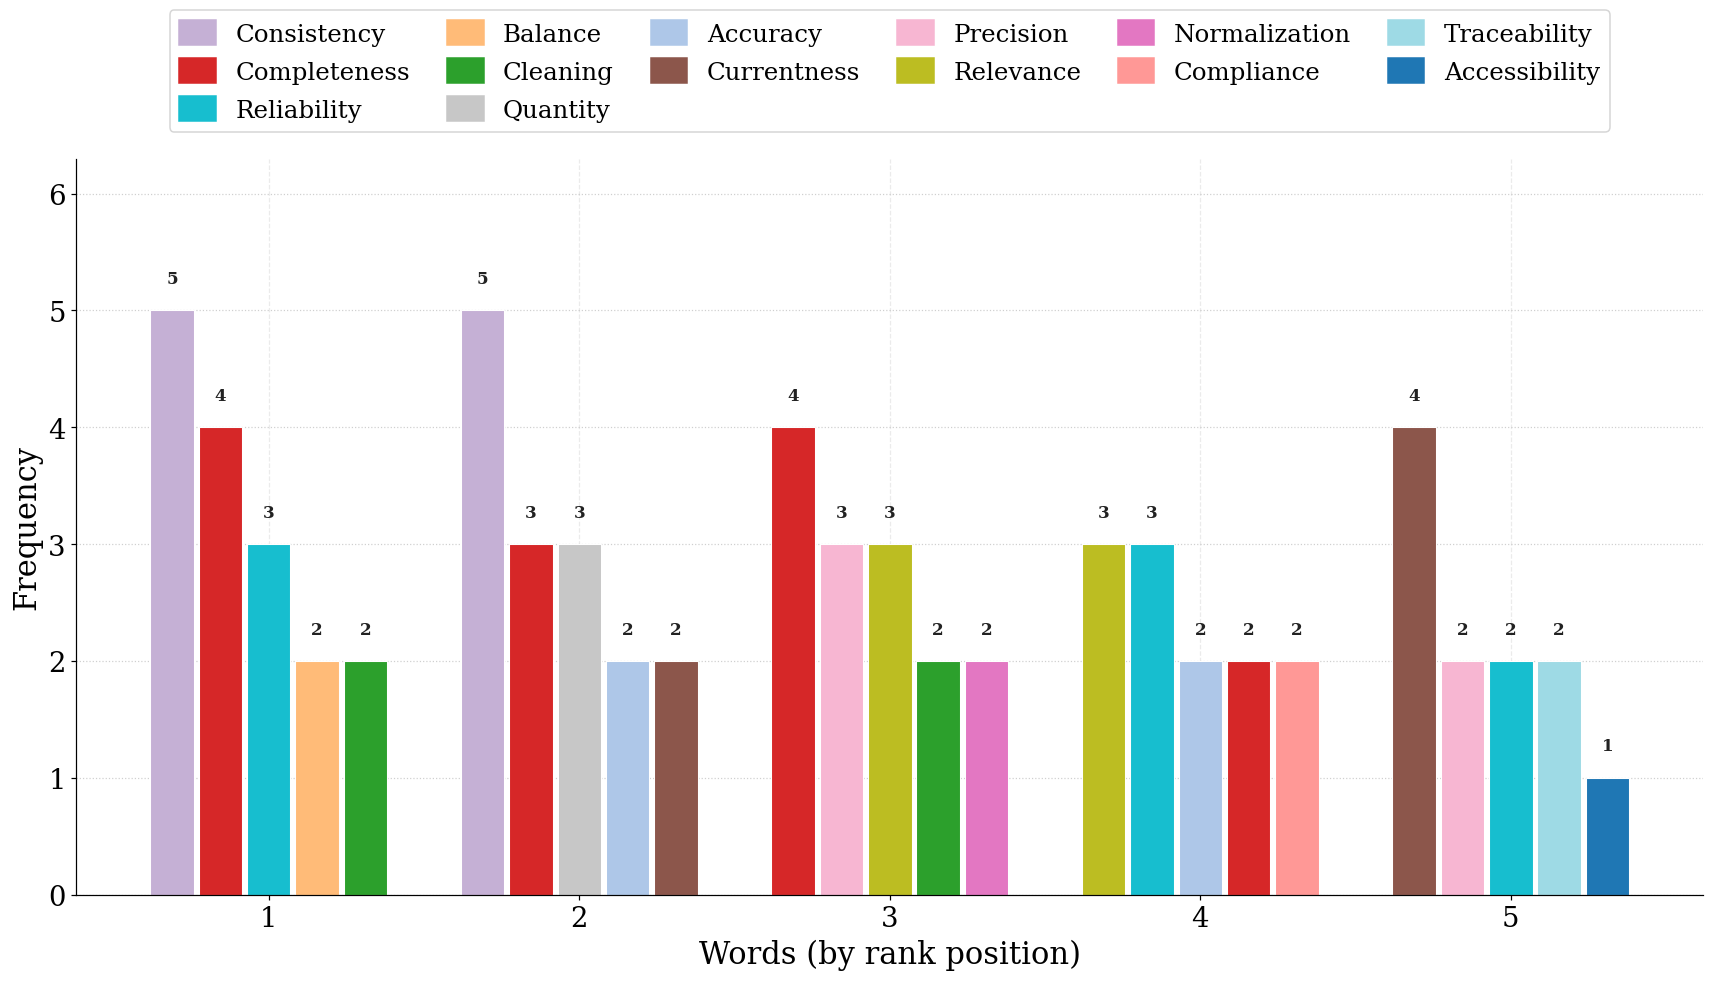

In [3]:
U.setup_matplotlib()

fig, ax = plt.subplots(figsize=(16, 9))  # ligeiramente maior para suportar fontes grandes

bar_width = 0.07
group_gap = 0.1
legend_handles = {}

for g_idx, pos in enumerate(positions):
    if pos not in top_words_per_pos:
        continue

    words_in_pos = top_words_per_pos[pos]
    group_center = g_idx * (TOP_N * bar_width + group_gap)

    for b_idx, (word, freq) in enumerate(words_in_pos.items()):
        x = group_center + b_idx * bar_width
        color = word_colors[word]

        ax.bar(x, freq, width=bar_width * 0.9,
               color=color, edgecolor='white', linewidth=0.7)

        if word not in legend_handles:
            legend_handles[word] = plt.Rectangle((0, 0), 1, 1, color=color)

        ax.text(x, freq + 0.2, str(int(freq)),
                ha='center', va='bottom',
                fontsize=11, fontweight='bold', color='#222222')  # 🔼 fonte maior

group_centers = [
    g * (TOP_N * bar_width + group_gap) + (TOP_N - 1) * bar_width / 2
    for g in range(len(positions))
]

ax.set_xticks(group_centers)
ax.set_xticklabels([str(p) for p in positions], fontsize=18)

ax.set_xlabel("Words (by rank position)", fontsize=20)
ax.set_ylabel("Frequency", fontsize=20)

ax.tick_params(axis='y', labelsize=18)

ax.spines[['top', 'right']].set_visible(False)
ax.yaxis.grid(True, linestyle=':', alpha=0.6)
ax.set_axisbelow(True)
ax.set_ylim(0, ax.get_ylim()[1] * 1.2)

ax.legend(
    legend_handles.values(), legend_handles.keys(),
    loc='lower center',
    bbox_to_anchor=(0.5, 1.02),  
    ncol=6,
    frameon=True,
    fontsize=16,               
    handlelength=1.5,
    handleheight=1.2,
    columnspacing=1.5
)

plt.tight_layout()
U.save_fig(fig, "../figures/q9_top_words_by_position.pdf")

## Q11 — Importance, Priority of Data Quality Characteristics

In [4]:
def _bootstrap_ci(
    long_df: pd.DataFrame,
    item_col: str,
    value_col: str,
    items: list,
    top_levels: list[int],
    bottom_levels: list[int],
    n_bootstrap: int = 1000,
    ci_level: float = 0.95,
    random_state: int | None = 42,
) -> pd.DataFrame:
    """Compute % top/bottom and Bootstrap CI for each item in *items*.

    Parameters
    ----------
    long_df       : long-format DataFrame with columns [item_col, value_col]
    items         : list of keys (values in item_col)
    top_levels    : iterable of Likert values that count as "positive" (e.g. [4, 5])
    bottom_levels : iterable of Likert values that count as "negative" (e.g. [1, 2])
    n_bootstrap   : number of bootstrap resamples (default 1000)
    ci_level      : confidence level, e.g. 0.95 for 95% CI (default 0.95)
    random_state  : seed for reproducibility (default 42)

    Returns
    -------
    DataFrame indexed by item key with columns for pct and CI (all in %).
    """
    rng = np.random.default_rng(random_state)
    alpha = 1 - ci_level
    rows = {}

    for key in items:
        s = long_df.loc[long_df[item_col] == key, value_col].dropna()
        n = len(s)
        if n == 0:
            rows[key] = {
                "pct_top2": float("nan"), "ci_lo": float("nan"), "ci_hi": float("nan"),
                "pct_bottom2": float("nan"), "ci_bottom_lo": float("nan"), "ci_bottom_hi": float("nan")
            }
            continue

        vals = s.values
        
        pct_top2 = s.isin(top_levels).mean() * 100
        pct_bottom2 = s.isin(bottom_levels).mean() * 100

        boot_indices = rng.integers(0, n, size=(n_bootstrap, n))
        
        boot_props_top = np.isin(vals[boot_indices], top_levels).mean(axis=1) * 100
        lo_top = np.percentile(boot_props_top, 100 * alpha / 2)
        hi_top = np.percentile(boot_props_top, 100 * (1 - alpha / 2))

        boot_props_bottom = np.isin(vals[boot_indices], bottom_levels).mean(axis=1) * 100
        lo_bottom = np.percentile(boot_props_bottom, 100 * alpha / 2)
        hi_bottom = np.percentile(boot_props_bottom, 100 * (1 - alpha / 2))

        rows[key] = {
            "pct_top2": pct_top2, "ci_lo": lo_top, "ci_hi": hi_top,
            "pct_bottom2": pct_bottom2, "ci_bottom_lo": lo_bottom, "ci_bottom_hi": hi_bottom
        }

    return pd.DataFrame(rows).T



In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams

rcParams["font.family"]      = "sans-serif"
rcParams["font.sans-serif"]  = ["DejaVu Sans", "Arial", "Helvetica", "Liberation Sans"]
rcParams["mathtext.fontset"] = "dejavusans"

PALETTE_LIKERT_5 = [
    "#3B1F6E",
    "#9B72CF",
    "#D9D9D9",
    "#7BC67E",
    "#1A6B3C",
]


def _bootstrap_ci(
    long_df, item_col, value_col, items,
    top_levels, bottom_levels,
    n_bootstrap=1000, ci_level=0.95, random_state=42,
):
    rng   = np.random.default_rng(random_state)
    alpha = 1 - ci_level
    rows  = {}
    for key in items:
        s = long_df.loc[long_df[item_col] == key, value_col].dropna()
        n = len(s)
        if n == 0:
            rows[key] = dict(pct_top2=np.nan, ci_lo=np.nan, ci_hi=np.nan,
                             pct_bottom2=np.nan, ci_bottom_lo=np.nan, ci_bottom_hi=np.nan)
            continue
        vals        = s.values
        pct_top2    = s.isin(top_levels).mean()    * 100
        pct_bottom2 = s.isin(bottom_levels).mean() * 100
        idx         = rng.integers(0, n, size=(n_bootstrap, n))
        boot_top    = np.isin(vals[idx], top_levels).mean(axis=1)    * 100
        boot_bottom = np.isin(vals[idx], bottom_levels).mean(axis=1) * 100
        rows[key] = dict(
            pct_top2     = pct_top2,
            ci_lo        = np.percentile(boot_top,    100 * alpha / 2),
            ci_hi        = np.percentile(boot_top,    100 * (1 - alpha / 2)),
            pct_bottom2  = pct_bottom2,
            ci_bottom_lo = np.percentile(boot_bottom, 100 * alpha / 2),
            ci_bottom_hi = np.percentile(boot_bottom, 100 * (1 - alpha / 2)),
        )
    return pd.DataFrame(rows).T


def diverging_stacked(
    long_df, item_col, value_col, item_labels, level_labels,
    figsize=(6.5, 5.5), palette=None,
    item_order=None,
    ci_df=None, ax=None, title=None,
    neg_label="Less favourable", pos_label="More favourable",
    show_pct_inside_threshold=4.0, footnote=None,
    show_ytick_labels=True,
):
    n_levels = len(level_labels)
    if palette is None:
        palette = PALETTE_LIKERT_5 if n_levels == 5 else [f"C{i}" for i in range(n_levels)]

    items      = list(item_order) if item_order is not None else list(item_labels.keys())
    items_plot = list(reversed(items))

    counts = (
        long_df.groupby(item_col)[value_col]
        .value_counts().unstack(fill_value=0)
        .reindex(index=items_plot, columns=range(1, n_levels + 1), fill_value=0)
    )
    pct = counts.div(counts.sum(axis=1), axis=0) * 100

    if n_levels == 5:
        neg_levels, neutral_lvl, pos_levels = [1, 2], 3, [4, 5]
    elif n_levels == 4:
        neg_levels, neutral_lvl, pos_levels = [1, 2], None, [3, 4]
    else:
        raise ValueError("diverging_stacked expects 4 or 5 levels")

    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=figsize)
    else:
        fig = ax.get_figure()

    y          = np.arange(len(items_plot))
    bar_height = 0.76
    neutral_half = (pct[neutral_lvl].values / 2) if neutral_lvl is not None \
                   else np.zeros(len(items_plot))

    # negative bars
    cur = -(neutral_half + pct[neg_levels[1]].values + pct[neg_levels[0]].values)
    for lvl, color in zip(neg_levels, palette[:len(neg_levels)]):
        widths = pct[lvl].values
        ax.barh(y, widths, left=cur, height=bar_height,
                color=color, edgecolor="white", linewidth=0.4,
                label=level_labels[lvl - 1])
        for i, w in enumerate(widths):
            if w < show_pct_inside_threshold: continue
            ax.text(cur[i] + w/2, y[i], f"{w:.0f}%", ha="center", va="center",
                    fontsize=9, color="white", fontweight="bold")
        cur += widths

    # neutral bar
    if neutral_lvl is not None:
        widths = pct[neutral_lvl].values
        ax.barh(y, widths, left=-widths/2, height=bar_height,
                color=palette[neutral_lvl - 1], edgecolor="white", linewidth=0.4,
                label=level_labels[neutral_lvl - 1])
        for i, w in enumerate(widths):
            if w < show_pct_inside_threshold: continue
            ax.text(-widths[i]/2 + w/2, y[i], f"{w:.0f}%",
                    ha="center", va="center", fontsize=10, color="#333333")

    # positive bars
    cur = neutral_half.copy()
    for lvl, color in zip(pos_levels, palette[-len(pos_levels):]):
        widths = pct[lvl].values
        ax.barh(y, widths, left=cur, height=bar_height,
                color=color, edgecolor="white", linewidth=0.4,
                label=level_labels[lvl - 1])
        for i, w in enumerate(widths):
            if w < show_pct_inside_threshold: continue
            ax.text(cur[i] + w/2, y[i], f"{w:.0f}%", ha="center", va="center",
                    fontsize=10, color="white", fontweight="bold")
        cur += widths

    # CI shadow band
    if ci_df is not None:
        ci_al    = ci_df.reindex(items_plot)
        band_h   = bar_height * 0.55
        if "pct_top2" in ci_al.columns:
            x_lo = neutral_half + ci_al["ci_lo"].values
            x_hi = neutral_half + ci_al["ci_hi"].values
            ax.barh(y, x_hi - x_lo, left=x_lo, height=band_h,
                    color="#888888", alpha=0.30, zorder=5, label="95% CI")
        if "pct_bottom2" in ci_al.columns:
            x_lo = -(neutral_half + ci_al["ci_bottom_hi"].values)
            x_hi = -(neutral_half + ci_al["ci_bottom_lo"].values)
            ax.barh(y, x_hi - x_lo, left=x_lo, height=band_h,
                    color="#888888", alpha=0.30, zorder=5)

    ax.axvline(0, color="#333333", linewidth=0.7, zorder=4, linestyle="--", alpha=0.4)

    ax.set_yticks(y)
    if show_ytick_labels:
        ax.set_yticklabels([item_labels[k] for k in items_plot], fontsize=10.5)
    else:
        ax.set_yticklabels([])
        ax.tick_params(axis="y", length=0)

    ax.set_xlabel("% of responses", fontsize=10.5)
    ax.set_xlim(-50, 100)
    ax.set_xticks([-50, -25, 0, 25, 50, 75, 100])
    ax.set_xticklabels(["50%","25%","0","25%","50%","75%","100%"], fontsize=9.5)
    ax.tick_params(axis="x", length=3)

    ax.grid(axis="x", color="#e0e0e0", linewidth=0.5, zorder=0)
    ax.grid(axis="y", visible=False)
    ax.set_axisbelow(True)
    for spine in ["top", "right", "left"]:
        ax.spines[spine].set_visible(False)
    ax.spines["bottom"].set_color("#cccccc")
    ax.margins(x=0.01)

    ax.text(0.167, 1.01, neg_label, ha="center", va="bottom",
            fontsize=10, fontweight="bold", color=palette[0], transform=ax.transAxes)
    ax.text(0.75, 1.01, pos_label, ha="center", va="bottom",
            fontsize=10, fontweight="bold", color=palette[-1], transform=ax.transAxes)

    if title:
        ax.set_title(title, fontsize=11.5, fontweight="bold", pad=38, loc="center")

    handles, labels_leg = ax.get_legend_handles_labels()
    seen = {}
    for h, l in zip(handles, labels_leg):
        if l not in seen:
            seen[l] = h
    ax.legend(list(seen.values()), list(seen.keys()),
              loc="upper center", bbox_to_anchor=(0.5, -0.13),
              ncol=len(seen), frameon=False, fontsize=9.5,
              handlelength=1.3, handleheight=0.85,
              borderpad=0, columnspacing=0.9)

    if standalone and footnote:
        fig.text(0.01, -0.04, footnote, ha="left", va="top",
                 fontsize=8.5, color="#555555",
                 bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="#cccccc", lw=0.8))

    return fig


def plot_importance_priority_combined(
    imp_long, pri_long, item_labels,
    imp_item_col="characteristic", imp_value_col="importance",
    pri_item_col="characteristic",  pri_value_col="priority",
    figsize=(15.0, 6.5),
    footnote=(
        "Percentages may not sum to 100 % due to rounding.  "
        "95 % CI = 95 % confidence interval of the percentage."
    ),
    save_func=None,
):
    items   = list(item_labels.keys())
    _imp_ci = _bootstrap_ci(imp_long, imp_item_col, imp_value_col, items,
                             top_levels=[4,5], bottom_levels=[1,2])
    _pri_ci = _bootstrap_ci(pri_long, pri_item_col, pri_value_col, items,
                             top_levels=[4,5], bottom_levels=[1,2])

    fig, (ax_imp, ax_pri) = plt.subplots(1, 2, figsize=figsize,
                                          gridspec_kw={"wspace": 0.04})

    diverging_stacked(
        imp_long, item_col=imp_item_col, value_col=imp_value_col,
        item_labels=item_labels, item_order=items,
        level_labels=["Not important","Slightly important","Neutral","Important","Very important"],
        ci_df=_imp_ci, ax=ax_imp,
        title="Perceived Importance of 13 Data Quality\nCharacteristics (Q11-Q12)",
        neg_label="Less important", pos_label="More important",
    )

    diverging_stacked(
        pri_long, item_col=pri_item_col, value_col=pri_value_col,
        item_labels=item_labels, item_order=items,
        level_labels=["Not a priority","Low priority","Neutral","High priority","Essential"],
        ci_df=_pri_ci, ax=ax_pri,
        title="Perceived Priority of 13 Data Quality\nCharacteristics (Q13-Q14)",
        neg_label="Lower priority", pos_label="Higher priority",
        show_ytick_labels=False,
    )

    fig.text(0.01, -0.02, footnote, ha="left", va="top", fontsize=9, color="#555555",
             bbox=dict(boxstyle="round,pad=0.45", fc="white", ec="#cccccc", lw=0.8))

    fig.tight_layout()

    if save_func is not None:
        save_func(fig, "importance_priority_diverging")

    return fig

C:\Users\kevin\AppData\Local\Temp\ipykernel_21528\661755884.py:36: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


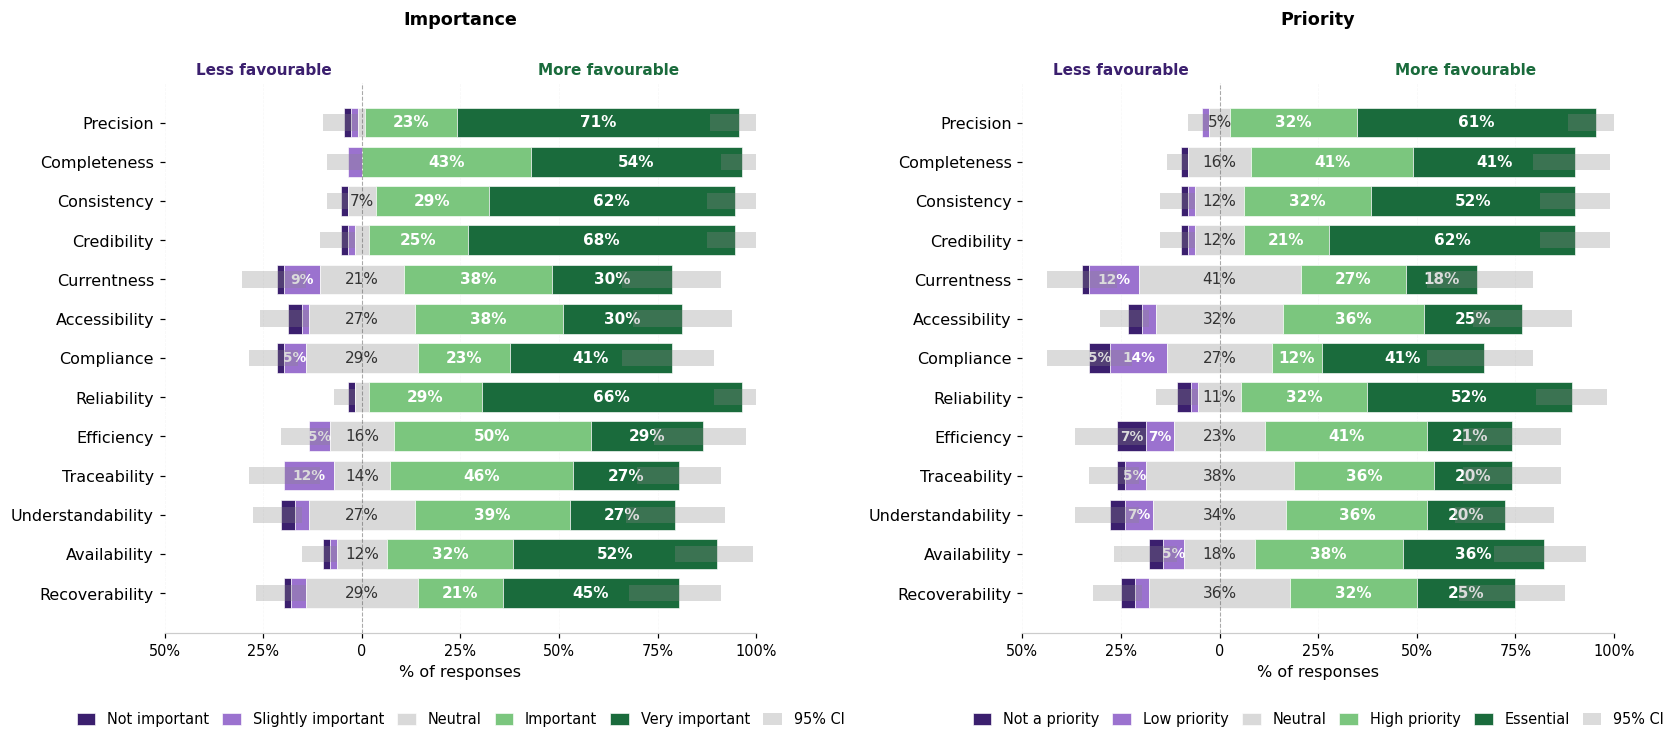

In [6]:
_imp_ci = _bootstrap_ci(
    imp_long, "characteristic", "importance",
    list(U.CHARACTERISTICS_PT.keys()),
    top_levels=[4, 5], bottom_levels=[1, 2]
)
_pri_ci = _bootstrap_ci(
    pri_long, "characteristic", "priority",
    list(U.CHARACTERISTICS_PT.keys()),
    top_levels=[4, 5], bottom_levels=[1, 2]
)

fig, (ax_imp, ax_pri) = plt.subplots(1, 2, figsize=(17.0, 6.5), gridspec_kw={"wspace": 0.45})

diverging_stacked(
    imp_long,
    item_col="characteristic",
    value_col="importance",
    item_labels=U.CHARACTERISTICS_PT,
    level_labels=["Not important", "Slightly important", "Neutral", "Important", "Very important"],
    ci_df=_imp_ci,
    ax=ax_imp,
    title="Importance",
)

diverging_stacked(
    pri_long,
    item_col="characteristic",
    value_col="priority",
    item_labels=U.CHARACTERISTICS_PT,
    level_labels=["Not a priority", "Low priority", "Neutral", "High priority", "Essential"],
    ci_df=_pri_ci,
    ax=ax_pri,
    title="Priority",
)

fig.tight_layout()
U.save_fig(fig, "importance_priority_diverging")
plt.show()

## 11. Aggregated skills — % "Above average/Very high"

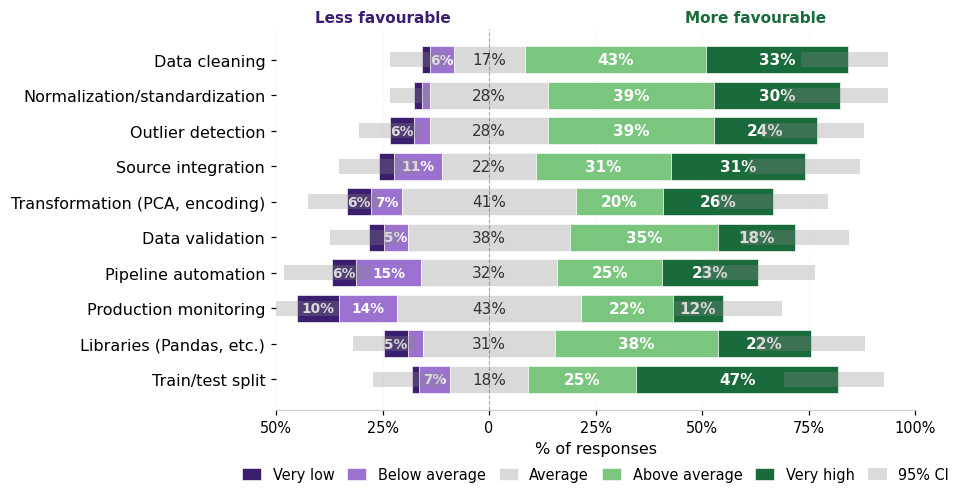

In [7]:
skills_renamed = skills_long.copy()
_skill_items = list(U.SKILL_LABELS_PT.keys())

_skill_ci = _bootstrap_ci(
    skills_renamed.dropna(),
    "activity",
    "skill",
    _skill_items,
    top_levels=[4, 5],
    bottom_levels=[1, 2],
)

fig = diverging_stacked(
    skills_renamed.dropna(),
    item_col="activity",
    value_col="skill",
    item_labels=U.SKILL_LABELS_PT,
    level_labels=["Very low", "Below average", "Average", "Above average", "Very high"],
    figsize=(7.5, 4.5),
    ci_df=_skill_ci,
)

U.save_fig(fig, "skills_diverging")
plt.show()

## Q16

In [8]:
raw = pd.read_excel(U.DATA_RAW / "full_quali.xlsx", engine="openpyxl")

q16 = raw["versioning_open"].value_counts(dropna=False)
n_total = len(raw)

# largura dinâmica baseada na maior resposta
labels = [str(resp) if pd.notna(resp) else "(no answer)" for resp in q16.index]
label_width = max(len("Response"), max(len(l) for l in labels))

print(f"Q16 — Data version control impact on data quality (N={n_total})\n")
print(f"{'Response':<{label_width}}  {'n':>6}  {'%':>7}")
print("-" * (label_width + 16))

for resp, n in q16.items():
    label = str(resp) if pd.notna(resp) else "(no answer)"
    pct = n / n_total * 100
    print(f"{label:<{label_width}}  {n:>6}  {pct:>6.1f}%")

print("-" * (label_width + 16))
print(f"{'Total':<{label_width}}  {n_total:>6}  {100:>6.1f}%")

Q16 — Data version control impact on data quality (N=56)

Response                                                                                                                  n        %
-----------------------------------------------------------------------------------------------------------------------------------
Ensures data consistency and traceability over time, allowing changes to the dataset to be documented and verified.      51    91.1%
Eliminates the need to document changes to the dataset, as all changes are automatically applied to the model.            3     5.4%
Increases the amount of data available, without the need to check consistency between versions.                           1     1.8%
I have no experience in this regard                                                                                       1     1.8%
-----------------------------------------------------------------------------------------------------------------------------------
Total        

 # Inferencial tests


## Spearman Rank Correlation — Importance × Priority (H1)

We formulate one hypothesis covering the relationship between the two perception dimensions assessed in this study:

- **H1**: Importance and priority are strongly correlated per characteristic (|ρ| ≥ 0.60, p < 0.05)
- **H1₀**: No strong correlation between importance and priority

We first applied the Shapiro–Wilk test (Shapiro & Wilk, 1965), which indicated non-normal distributions. Therefore, we used Spearman's rank correlation coefficient (Wohlin et al., 2012) with a 95% confidence level (p < 0.05). Color coding follows Salkind (2012): very strong |ρ| ≥ 0.80, strong 0.60–0.79, moderate 0.40–0.59, weak 0.20–0.39.


In [9]:
from scipy.stats import shapiro, spearmanr
rng = np.random.default_rng(42)

# Step 1 — Shapiro-Wilk: confirm non-normality to justify Spearman
sw_results = []
for col_imp, col_pri in zip(U.IMP_COLS, U.PRI_COLS):
    char = col_imp.split("_", 1)[1]
    _, p_imp = shapiro(df[col_imp].dropna())
    _, p_pri = shapiro(df[col_pri].dropna())
    sw_results.append({
        "characteristic": char,
        "p_imp": p_imp, "normal_imp": p_imp >= 0.05,
        "p_pri": p_pri, "normal_pri": p_pri >= 0.05
    })

sw_df = pd.DataFrame(sw_results)
n_nn_imp = (~sw_df["normal_imp"]).sum()
n_nn_pri = (~sw_df["normal_pri"]).sum()

print(f"(IMP) Shapiro-Wilk: {n_nn_imp}/13 importance distributions non-normal (p<0.05)")
print(f"(PRI) Shapiro-Wilk: {n_nn_pri}/13 priority distributions non-normal (p<0.05)")
print("→ Non-normal distributions justify Spearman's rank correlation.\n")

(IMP) Shapiro-Wilk: 13/13 importance distributions non-normal (p<0.05)
(PRI) Shapiro-Wilk: 13/13 priority distributions non-normal (p<0.05)
→ Non-normal distributions justify Spearman's rank correlation.



In [10]:
# Step 2 — Spearman ρ per characteristic
def _salkind_strength(rho: float) -> str:
    r = abs(rho)
    if r >= 0.80:   return "Very Strong"
    elif r >= 0.60: return "Strong"
    elif r >= 0.40: return "Moderate"
    elif r >= 0.20: return "Weak"
    return "Very Weak"


spearman_rows = []
for col_imp, col_pri in zip(U.IMP_COLS, U.PRI_COLS):
    char = col_imp.split("_", 1)[1]
    mask = df[col_imp].notna() & df[col_pri].notna()
    rho, p = spearmanr(df.loc[mask, col_imp], df.loc[mask, col_pri])

    spearman_rows.append({
        "characteristic": char,
        "n": int(mask.sum()),
        "rho": float(rho),
        "p": float(p),
        "sig": float(p) < 0.05,
        "strength": _salkind_strength(float(rho)),
    })

spearman_df = pd.DataFrame(spearman_rows)

n_sig = spearman_df["sig"].sum()
print(f"H1 — significant (p<0.05): {n_sig}/13 characteristics")

display_df = spearman_df.copy()
display_df.index = display_df["characteristic"].map(U.CHARACTERISTICS_EN)
display_df = display_df[["rho"]].rename(columns={"rho": "Imp × Pri (H1)"})

def _salkind_color(val):
    if not isinstance(val, (int, float)) or pd.isna(val):
        return ""
    r = abs(val)
    if r >= 0.80:   return "background-color: #1a6b3c; color: white"
    elif r >= 0.60: return "background-color: #7bc67e"
    elif r >= 0.40: return "background-color: #ffe066"
    elif r >= 0.20: return "background-color: #e57373; color: white"
    return ""


styled_table = (
    display_df.style
    .map(_salkind_color)
    .format("{:.3f}")
    .set_caption(
        "Spearman ρ between Importance (Q11) and Priority (Q13) per characteristic. "
        "Color: dark green ≥ 0.80 (very strong), light green ≥ 0.60 (strong), "
        "yellow ≥ 0.40 (moderate), red ≥ 0.20 (weak) — Salkind (2012)."
    )
)

display(styled_table)

H1 — significant (p<0.05): 13/13 characteristics


,Imp × Pri (H1)
characteristic,
Precision,0.637
Completeness,0.585
Consistency,0.589
Credibility,0.573
Currentness,0.714
Accessibility,0.542
Compliance,0.832
Reliability,0.544
Efficiency,0.526


raw form

In [11]:
# Build display table mimicking the reference paper (one column per hypothesis pair)
display_df = spearman_df.copy()
display_df.index = display_df["characteristic"].map(U.CHARACTERISTICS_EN)
display_df = display_df[["rho"]].rename(columns={"rho": "Imp × Pri (H1)"})

def _salkind_color(val):
    if not isinstance(val, (int, float)) or pd.isna(val):
        return ""
    r = abs(val)
    if r >= 0.80:   return "background-color: #1a6b3c; color: white"
    elif r >= 0.60: return "background-color: #7bc67e"
    elif r >= 0.40: return "background-color: #ffe066"
    elif r >= 0.20: return "background-color: #e57373; color: white"
    return ""

styled_table = (
    display_df.style
    .map(_salkind_color)
    .format("{:.3f}")
    .set_caption(
        "Spearman ρ between Importance (Q11) and Priority (Q13) per characteristic. "
        "Color: dark green ≥ 0.80 (very strong), light green ≥ 0.60 (strong), "
        "yellow ≥ 0.40 (moderate), red ≥ 0.20 (weak) — Salkind (2012)."
    )
    .set_table_styles([
        {"selector": "th.col_heading", "props": [("text-align", "center"), ("font-weight", "bold")]},
        {"selector": "td", "props": [("text-align", "center"), ("padding", "4px 16px")]},
        {"selector": "th.row_heading", "props": [("text-align", "left"), ("padding", "4px 12px")]},
    ])
)

display(styled_table)

# --- LaTeX export (raw table, exact format) ---
_caption = (
    "Spearman's rank correlation coefficient ($\\rho$) between Importance (Q11) "
    "and Priority (Q13) for each data quality characteristic. "
    "Confidence level: 95\\% ($p < 0.05$). "
    "Correlation strength classification follows Salkind (2012)."
)
_label = "tab:spearman-imp-pri"

spearman_out = spearman_df[["characteristic", "rho", "strength", "p"]]

_body = (
    spearman_out.style
    .hide(axis="index")
    .format({"rho": "{:.6f}", "p": "{:.6f}"})
    .to_latex(hrules=True, column_format="lrlr")
)

_tex = (
    "\\begin{table}[t]\n"
    f"  \\caption{{{_caption}}}\n"
    f"  \\label{{{_label}}}\n"
    "  \\centering\n"
    "  \\small\n"
    + _body +
    "\\end{table}\n"
)

(TABLES / "spearman_imp_vs_pri.tex").write_text(_tex, encoding="utf-8")
print("[saved] tables/spearman_imp_vs_pri.tex")

,Imp × Pri (H1)
characteristic,
Precision,0.637
Completeness,0.585
Consistency,0.589
Credibility,0.573
Currentness,0.714
Accessibility,0.542
Compliance,0.832
Reliability,0.544
Efficiency,0.526


[saved] tables/spearman_imp_vs_pri.tex
